# 📚 Revisão Sistemática de Literatura (PRISMA 2020)
## Inteligência Artificial para Aprendizado e Análise de Performance de Guitarra Elétrica

Este notebook implementa o workflow completo para uma Revisão Sistemática de Literatura seguindo as diretrizes PRISMA 2020.

**Tópico**: Aplicação de Inteligência Artificial para aprendizado de guitarra elétrica, análise de performance e sistemas de feedback automático.

**Período**: 2020-2026

**Idioma**: Inglês

In [27]:
# Importações necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import json
from difflib import SequenceMatcher
import warnings
warnings.filterwarnings('ignore')

# Configurações
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Criar diretórios se não existirem
Path("dataset").mkdir(exist_ok=True)
Path("prisma").mkdir(exist_ok=True)

print("✅ Ambiente configurado com sucesso!")

✅ Ambiente configurado com sucesso!


## 1. ESTÁGIO DE IDENTIFICAÇÃO (PRISMA 2020)

### 1.1 Carregamento do Dataset Completo

Carregamos o dataset completo exportado do Google Scholar via Publish or Perish.

In [28]:
# Carregar dataset completo
df_raw = pd.read_csv('dataset/dataset.csv', encoding='utf-8')
print(f"✅ Dataset carregado: {len(df_raw)} registros")

# Mapear colunas do Publish or Perish para formato padrão
identified_records = pd.DataFrame({
    'title': df_raw['Title'],
    'authors': df_raw['Authors'],
    'year': df_raw['Year'].astype(str).str.replace('.0', '', regex=False),
    'doi': df_raw['DOI'].fillna(''),
    'abstract': df_raw['Abstract'].fillna(''),
    'url': df_raw['ArticleURL'].fillna(''),
    'source': 'Google Scholar',
    'publisher': df_raw['Publisher'].fillna(''),
    'cites': df_raw['Cites'].fillna(0)
})

# Filtrar por período 2020-2026
identified_records['year_num'] = pd.to_numeric(identified_records['year'], errors='coerce')
identified_records = identified_records[
    (identified_records['year_num'] >= 2020) & 
    (identified_records['year_num'] <= 2026)
].copy()
identified_records = identified_records.drop(columns=['year_num'])

print(f"✅ Após filtrar período 2020-2026: {len(identified_records)} registros")
print(f"\nDistribuição por ano:")
print(identified_records['year'].value_counts().sort_index())

✅ Dataset carregado: 998 registros
✅ Após filtrar período 2020-2026: 598 registros

Distribuição por ano:
year
2020    107
2021    108
2022    109
2023    134
2024     88
2025     52
Name: count, dtype: int64


## 2. ESTÁGIO DE TRIAGEM (PRISMA 2020)

### 2.1 Processo de Desduplicação

A desduplicação é realizada em três etapas:
1. Desduplicação baseada em DOI
2. Correspondência exata de título (títulos normalizados)
3. Correspondência de similaridade fuzzy de título (≥ 94%)

In [ ]:
# Desduplicação: 1) DOI, 2) Título exato, 3) Título similar (≥94%)
import re

if not identified_records.empty:
    df = identified_records.copy()
    original_count = len(df)
    
    # Normalizar títulos
    df['title_norm'] = df['title'].fillna('').astype(str).str.lower().str.replace(r'[^\w\s]', '', regex=True).str.replace(r'\s+', ' ', regex=True)
    
    # 1. Por DOI (remover vazios primeiro)
    if 'doi' in df.columns:
        df_with_doi = df[df['doi'].notna() & (df['doi'] != '')]
        df_without_doi = df[df['doi'].isna() | (df['doi'] == '')]
        df_with_doi = df_with_doi.drop_duplicates(subset=['doi'], keep='first')
        df = pd.concat([df_with_doi, df_without_doi], ignore_index=True)
    
    # 2. Por título exato
    df = df.drop_duplicates(subset=['title_norm'], keep='first')
    
    # 3. Por similaridade fuzzy
    to_remove = set()
    titles = df['title_norm'].values
    for i in range(len(titles)):
        if i in to_remove:
            continue
        for j in range(i+1, len(titles)):
            if j in to_remove:
                continue
            if SequenceMatcher(None, titles[i], titles[j]).ratio() >= 0.94:
                to_remove.add(j)
    df = df.drop(df.index[list(to_remove)])
    df = df.drop(columns=['title_norm'])
    
    deduplicated_records = df
    deduplicated_records.to_csv('dataset/literature_dedup.csv', index=False, encoding='utf-8')
    print(f"✅ Desduplicação: {original_count} → {len(deduplicated_records)} registros")
    print(f"   Removidos: {original_count - len(deduplicated_records)} duplicatas")
else:
    deduplicated_records = pd.DataFrame()
    print("⚠️ Nenhum registro para desduplicar")

✅ Desduplicação: 598 → 595 registros
   Removidos: 3 duplicatas


### 2.2 Critérios de Inclusão e Exclusão

#### Critérios de Inclusão:
- ✅ Abordam IA, aprendizado de máquina ou sistemas inteligentes
- ✅ Focam em guitarra elétrica ou contextos de instrumentos de corda diretamente transferíveis
- ✅ Envolvem aprendizado, análise de performance ou feedback
- ✅ Escritos em inglês
- ✅ Publicados entre 2020 e 2026

#### Critérios de Exclusão:
- ❌ Focam em composição musical, síntese de som ou reconhecimento de fala
- ❌ Abordam MIR sem objetivos educacionais ou de avaliação de performance
- ❌ Não envolvem qualquer método baseado em IA
- ❌ São duplicatas, pôsteres ou apenas resumos

### 2.3 Triagem Automática de Título e Resumo

Realizamos triagem automática baseada em palavras-chave e critérios de inclusão/exclusão. O sistema analisa título e resumo de cada estudo e classifica automaticamente como 'yes' (incluir) ou 'no' (excluir).

**Critérios automáticos:**
- ✅ **Incluir**: Estudos que mencionam IA/ML **E** (guitarra **OU** aprendizado/performance)
- ❌ **Excluir**: Estudos sobre outros instrumentos, síntese de som, reconhecimento de fala, ou MIR sem objetivo educacional

O arquivo gerado pode ser revisado e ajustado manualmente se necessário.

In [35]:
# Triagem automática baseada em palavras-chave e critérios
def auto_screen_study(title, abstract):
    """
    Realiza triagem automática baseada em palavras-chave
    Retorna: ('yes' ou 'no', motivo_exclusao)
    """
    # Normalizar texto
    title_lower = str(title).lower() if pd.notna(title) else ''
    abstract_lower = str(abstract).lower() if pd.notna(abstract) else ''
    text = title_lower + ' ' + abstract_lower
    
    # Palavras-chave de INCLUSÃO (devem estar presentes)
    inclusion_keywords = [
        # IA/ML
        'artificial intelligence', 'machine learning', 'deep learning', 'neural network',
        'ai', 'ml', 'cnn', 'rnn', 'lstm', 'transformer', 'classifier', 'regression',
        # Guitarra/Instrumento
        'guitar', 'electric guitar', 'bass guitar', 'string instrument',
        # Aprendizado/Performance
        'learning', 'teaching', 'tutoring', 'instruction', 'education',
        'performance', 'skill', 'practice', 'feedback', 'evaluation', 'assessment',
        'technique', 'playing', 'musician', 'player'
    ]
    
    # Palavras-chave de EXCLUSÃO (se presentes, excluir)
    exclusion_keywords = [
        # Não relacionado a guitarra
        'piano', 'violin', 'viola', 'cello', 'drums', 'percussion', 'voice', 'singing',
        # Composição/Síntese (sem foco em aprendizado)
        'composition', 'synthesis', 'sound synthesis', 'audio synthesis',
        # Reconhecimento de fala (sem foco em instrumento)
        'speech recognition', 'voice recognition', 'speaker recognition',
        # MIR genérico sem objetivo educacional
        'music information retrieval', 'mir', 'music retrieval', 'music search',
        # Outros
        'poster', 'abstract only', 'workshop abstract'
    ]
    
    # Verificar exclusões primeiro
    for keyword in exclusion_keywords:
        if keyword in text:
            return ('no', f'Contém palavra-chave de exclusão: {keyword}')
    
    # Verificar se tem pelo menos uma palavra de IA/ML
    has_ai = any(kw in text for kw in ['artificial intelligence', 'machine learning', 'deep learning', 
                                        'neural network', ' ai ', ' ml ', 'cnn', 'rnn', 'lstm', 
                                        'classifier', 'regression', 'transformer'])
    
    # Verificar se tem palavra relacionada a guitarra
    has_guitar = any(kw in text for kw in ['guitar', 'bass'])
    
    # Verificar se tem palavra relacionada a aprendizado/performance
    has_learning = any(kw in text for kw in ['learning', 'teaching', 'tutoring', 'instruction', 
                                             'performance', 'skill', 'practice', 'feedback', 
                                             'evaluation', 'assessment', 'technique', 'playing'])
    
    # Critérios de inclusão: deve ter IA/ML E (guitarra OU aprendizado/performance)
    if has_ai and (has_guitar or has_learning):
        return ('yes', '')
    elif has_ai and not has_guitar and not has_learning:
        return ('no', 'Tem IA/ML mas não relacionado a guitarra ou aprendizado/performance')
    elif not has_ai and (has_guitar or has_learning):
        return ('no', 'Relacionado a guitarra/aprendizado mas não menciona IA/ML')
    else:
        return ('no', 'Não atende aos critérios de inclusão')

# Aplicar triagem automática
if not deduplicated_records.empty:
    template = deduplicated_records.copy()
    
    # Aplicar função de triagem automática
    results = template.apply(
        lambda row: auto_screen_study(row['title'], row['abstract']), 
        axis=1
    )
    
    template['include_title_screening'] = results.apply(lambda x: x[0])
    template['exclusion_reason'] = results.apply(lambda x: x[1])
    
    # Selecionar colunas relevantes
    cols = ['title', 'abstract', 'authors', 'year', 'doi', 'source', 
            'include_title_screening', 'exclusion_reason']
    cols = [c for c in cols if c in template.columns]
    cols.extend([c for c in template.columns if c not in cols])
    
    template_screening = template[cols]
    template_screening.to_csv('dataset/title_abstract_screening_template.csv', 
                             index=False, encoding='utf-8')
    
    # Estatísticas
    included_count = (template_screening['include_title_screening'] == 'yes').sum()
    excluded_count = (template_screening['include_title_screening'] == 'no').sum()
    
    print(f"✅ Triagem automática concluída!")
    print(f"   Total de estudos: {len(template_screening)}")
    print(f"   ✅ Incluídos automaticamente: {included_count}")
    print(f"   ❌ Excluídos automaticamente: {excluded_count}")
    print(f"\n💡 O arquivo foi salvo com as triagens automáticas.")
    print(f"   Você pode revisar e ajustar manualmente se necessário.")
    print(f"   Arquivo: dataset/title_abstract_screening_template.csv")
else:
    print("⚠️ Nenhum registro para criar template")

✅ Triagem automática concluída!
   Total de estudos: 595
   ✅ Incluídos automaticamente: 427
   ❌ Excluídos automaticamente: 168

💡 O arquivo foi salvo com as triagens automáticas.
   Você pode revisar e ajustar manualmente se necessário.
   Arquivo: dataset/title_abstract_screening_template.csv


### 2.4 Processamento dos Resultados da Triagem

Processa os resultados da triagem automática (ou manual, se você revisou o arquivo). Gera os arquivos de estudos incluídos e excluídos.

In [36]:
# Processar resultados da triagem
try:
    screening_results = pd.read_csv('dataset/title_abstract_screening_template.csv', encoding='utf-8')
    
    if 'include_title_screening' not in screening_results.columns:
        print("⚠️ Coluna 'include_title_screening' não encontrada.")
        print("   Preencha o template primeiro.")
        included_after_screening = None
        excluded_after_screening = None
    else:
        # Converter para string e tratar valores nulos
        screening_results['include_title_screening'] = screening_results['include_title_screening'].fillna('').astype(str)
        
        included_after_screening = screening_results[
            screening_results['include_title_screening'].str.lower().str.strip() == 'yes'
        ].copy()
        
        excluded_after_screening = screening_results[
            screening_results['include_title_screening'].str.lower().str.strip() == 'no'
        ].copy()
        
        included_after_screening.to_csv('dataset/studies_included_after_screening.csv', 
                                       index=False, encoding='utf-8')
        excluded_after_screening.to_csv('dataset/studies_excluded_after_screening.csv', 
                                       index=False, encoding='utf-8')
        
        print(f"✅ Triagem processada:")
        print(f"   Incluídos: {len(included_after_screening)}")
        print(f"   Excluídos: {len(excluded_after_screening)}")
        
        if not excluded_after_screening.empty and 'exclusion_reason' in excluded_after_screening.columns:
            print(f"\n📊 Razões de exclusão:")
            reasons = excluded_after_screening['exclusion_reason'].value_counts()
            for reason, count in reasons.items():
                if pd.notna(reason) and str(reason).strip():
                    print(f"   - {reason}: {count}")
except FileNotFoundError:
    included_after_screening = None
    excluded_after_screening = None
    print("⚠️ Arquivo title_abstract_screening_template.csv não encontrado.")
    print("   Execute a célula anterior para criar o template primeiro.")
except Exception as e:
    included_after_screening = None
    excluded_after_screening = None
    print(f"⚠️ Erro: {e}")

✅ Triagem processada:
   Incluídos: 427
   Excluídos: 168

📊 Razões de exclusão:
   - Relacionado a guitarra/aprendizado mas não menciona IA/ML: 59
   - Contém palavra-chave de exclusão: piano: 46
   - Contém palavra-chave de exclusão: composition: 9
   - Contém palavra-chave de exclusão: synthesis: 9
   - Contém palavra-chave de exclusão: violin: 8
   - Contém palavra-chave de exclusão: voice: 6
   - Contém palavra-chave de exclusão: drums: 6
   - Tem IA/ML mas não relacionado a guitarra ou aprendizado/performance: 6
   - Contém palavra-chave de exclusão: mir: 4
   - Contém palavra-chave de exclusão: music information retrieval: 4
   - Contém palavra-chave de exclusão: singing: 3
   - Contém palavra-chave de exclusão: cello: 3
   - Não atende aos critérios de inclusão: 3
   - Contém palavra-chave de exclusão: poster: 1
   - Contém palavra-chave de exclusão: speech recognition: 1


## 3. ESTÁGIO DE ELEGIBILIDADE (PRISMA 2020)

### 3.1 Template de Extração de Dados

Criamos um template padronizado para extração de dados durante a leitura do texto completo.

In [37]:
# Criar template de extração de dados
if included_after_screening is not None and not included_after_screening.empty:
    extraction_template = included_after_screening.copy()
    
    # Adicionar campos de extração
    fields = ['objectives', 'study_design', 'ai_techniques', 'data_sources', 
              'feedback_type', 'performance_dimensions', 'results', 'limitations', 
              'future_work', 'participants', 'evaluation_metrics', 'publication_type', 'country']
    
    for field in fields:
        if field not in extraction_template.columns:
            extraction_template[field] = ''
    
    extraction_template.to_csv('dataset/data_extraction_template.csv', 
                              index=False, encoding='utf-8')
    print(f"✅ Template de extração criado: dataset/data_extraction_template.csv")
    print(f"   Total de estudos: {len(extraction_template)}")
    print(f"\n📝 Preencha todos os campos durante a leitura do texto completo")
else:
    print("⚠️ Execute a triagem primeiro")

✅ Template de extração criado: dataset/data_extraction_template.csv
   Total de estudos: 427

📝 Preencha todos os campos durante a leitura do texto completo


### 3.2 Template de Avaliação de Qualidade / Risco de Viés

Criamos um template para avaliação sistemática da qualidade metodológica e risco de viés de cada estudo.

In [38]:
# Criar template de avaliação de qualidade
if included_after_screening is not None and not included_after_screening.empty:
    quality_template = included_after_screening[['title']].copy() if 'title' in included_after_screening.columns else pd.DataFrame()
    
    # Adicionar identificadores
    for col in ['doi', 'authors', 'year']:
        if col in included_after_screening.columns:
            quality_template[col] = included_after_screening[col]
    
    # Critérios de avaliação (escala 1-5)
    criteria = ['methodological_clarity', 'ai_appropriateness', 'dataset_quality', 
                'results_transparency', 'replicability', 'sample_size_adequacy', 'evaluation_rigor']
    
    for criterion in criteria:
        quality_template[criterion] = ''
        quality_template[f'{criterion}_notes'] = ''
    
    quality_template['overall_quality_score'] = ''
    quality_template['risk_of_bias'] = ''  # baixo, médio, alto
    quality_template['quality_notes'] = ''
    
    quality_template.to_csv('dataset/quality_assessment_template.csv', 
                           index=False, encoding='utf-8')
    print(f"✅ Template de qualidade criado: dataset/quality_assessment_template.csv")
    print(f"   Total de estudos: {len(quality_template)}")
    print(f"\n📝 Avalie cada critério (1-5) e classifique o risco de viés")
else:
    print("⚠️ Execute a triagem primeiro")

✅ Template de qualidade criado: dataset/quality_assessment_template.csv
   Total de estudos: 427

📝 Avalie cada critério (1-5) e classifique o risco de viés


## 4. ESTÁGIO DE INCLUSÃO (PRISMA 2020)

### 4.1 Geração do Diagrama de Fluxo PRISMA

Geramos automaticamente o diagrama de fluxo PRISMA com as contagens de cada estágio.

✅ Diagrama PRISMA salvo em: prisma/prisma_diagram.png

📊 Contagens PRISMA:
   identified: 598
   after_deduplication: 595
   screened: 595
   excluded: 168
   included_screening: 427
   included_final: 427


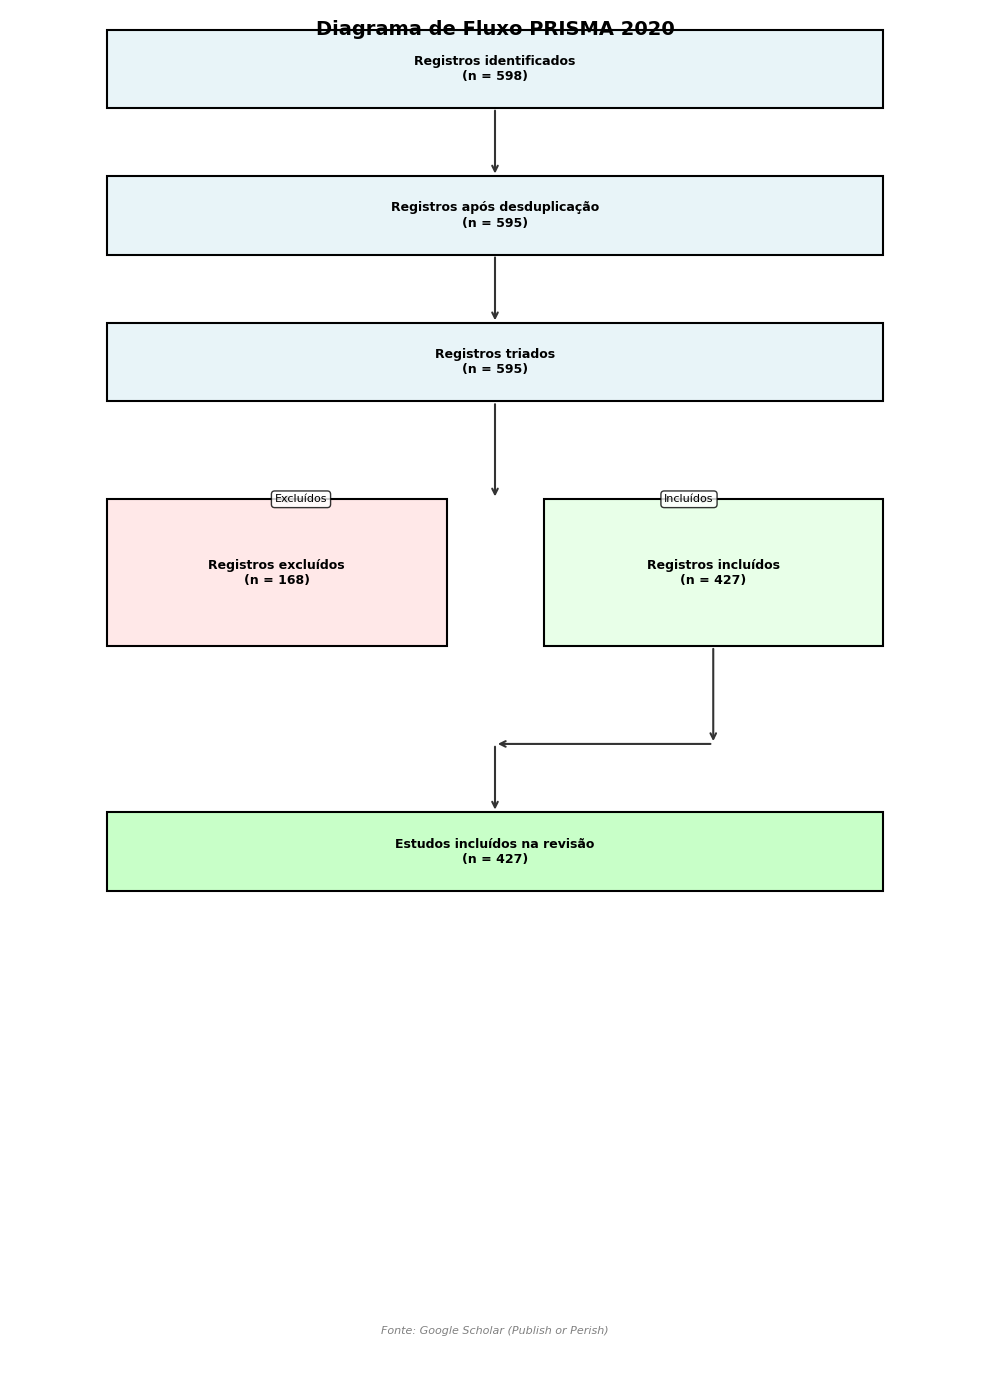

In [39]:
# Gerar diagrama PRISMA
def create_prisma_diagram():
    # Coletar contagens
    counts = {
        'identified': len(identified_records) if not identified_records.empty else 0,
        'after_deduplication': len(deduplicated_records) if not deduplicated_records.empty else 0,
        'screened': len(deduplicated_records) if not deduplicated_records.empty else 0,
        'excluded': 0,
        'included_screening': 0,
        'included_final': 0
    }
    
    # Carregar dados de triagem se disponíveis
    try:
        if included_after_screening is not None:
            counts['included_screening'] = len(included_after_screening)
        else:
            df_inc = pd.read_csv('dataset/studies_included_after_screening.csv', encoding='utf-8')
            counts['included_screening'] = len(df_inc)
    except:
        pass
    
    try:
        if excluded_after_screening is not None:
            counts['excluded'] = len(excluded_after_screening)
        else:
            df_exc = pd.read_csv('dataset/studies_excluded_after_screening.csv', encoding='utf-8')
            counts['excluded'] = len(df_exc)
    except:
        pass
    
    counts['included_final'] = counts['included_screening']
    
    # Salvar contagens
    with open('prisma/prisma_counts.json', 'w', encoding='utf-8') as f:
        json.dump(counts, f, indent=2, ensure_ascii=False)
    
    # Criar diagrama
    fig, ax = plt.subplots(1, 1, figsize=(10, 14))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 14)
    ax.axis('off')
    
    # Caixas
    boxes = [
        {'x': 1, 'y': 13, 'w': 8, 'h': 0.8, 'text': f'Registros identificados\n(n = {counts["identified"]})', 'color': '#E8F4F8'},
        {'x': 1, 'y': 11.5, 'w': 8, 'h': 0.8, 'text': f'Registros após desduplicação\n(n = {counts["after_deduplication"]})', 'color': '#E8F4F8'},
        {'x': 1, 'y': 10, 'w': 8, 'h': 0.8, 'text': f'Registros triados\n(n = {counts["screened"]})', 'color': '#E8F4F8'},
        {'x': 1, 'y': 7.5, 'w': 3.5, 'h': 1.5, 'text': f'Registros excluídos\n(n = {counts["excluded"]})', 'color': '#FFE8E8'},
        {'x': 5.5, 'y': 7.5, 'w': 3.5, 'h': 1.5, 'text': f'Registros incluídos\n(n = {counts["included_screening"]})', 'color': '#E8FFE8'},
        {'x': 1, 'y': 5, 'w': 8, 'h': 0.8, 'text': f'Estudos incluídos na revisão\n(n = {counts["included_final"]})', 'color': '#C8FFC8'},
    ]
    
    for box in boxes:
        rect = mpatches.Rectangle((box['x'], box['y']), box['w'], box['h'],
                                 linewidth=1.5, edgecolor='black', facecolor=box['color'], zorder=1)
        ax.add_patch(rect)
        ax.text(box['x'] + box['w']/2, box['y'] + box['h']/2, box['text'],
               ha='center', va='center', fontsize=9, weight='bold', zorder=2)
    
    # Setas
    arrows = [
        {'from': (5, 13), 'to': (5, 12.3), 'label': ''},
        {'from': (5, 11.5), 'to': (5, 10.8), 'label': ''},
        {'from': (5, 10), 'to': (5, 9), 'label': ''},
        {'from': (3.25, 9), 'to': (2.75, 9), 'label': 'Excluídos'},
        {'from': (6.75, 9), 'to': (7.25, 9), 'label': 'Incluídos'},
        {'from': (7.25, 7.5), 'to': (7.25, 6.5), 'label': ''},
        {'from': (7.25, 6.5), 'to': (5, 6.5), 'label': ''},
        {'from': (5, 6.5), 'to': (5, 5.8), 'label': ''},
    ]
    
    for arrow in arrows:
        ax.annotate('', xy=arrow['to'], xytext=arrow['from'],
                   arrowprops=dict(arrowstyle='->', lw=1.5, color='#333333'))
        if arrow['label']:
            mid_x = (arrow['from'][0] + arrow['to'][0]) / 2
            mid_y = (arrow['from'][1] + arrow['to'][1]) / 2
            ax.text(mid_x, mid_y, arrow['label'], ha='center', va='center',
                   fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    ax.text(5, 13.8, 'Diagrama de Fluxo PRISMA 2020', 
           ha='center', va='center', fontsize=14, weight='bold')
    ax.text(5, 0.5, 'Fonte: Google Scholar (Publish or Perish)', 
           ha='center', va='center', fontsize=8, style='italic', color='gray')
    
    plt.tight_layout()
    plt.savefig('prisma/prisma_diagram.png', dpi=300, bbox_inches='tight')
    print(f"✅ Diagrama PRISMA salvo em: prisma/prisma_diagram.png")
    print(f"\n📊 Contagens PRISMA:")
    for key, value in counts.items():
        print(f"   {key}: {value}")
    plt.show()

# Gerar diagrama
create_prisma_diagram()

### 4.2 Checklist PRISMA 2020

Geramos um checklist PRISMA 2020 para documentar a conformidade metodológica.

In [ ]:
# Criar checklist PRISMA
checklist = """# Checklist PRISMA 2020

## TÍTULO
- [ ] 1. Identificar o relatório como uma revisão sistemática.

## RESUMO
- [ ] 2. Ver resumo estruturado.

## INTRODUÇÃO
- [ ] 3. Justificar a revisão no contexto do que já é conhecido.
- [ ] 4. Fornecer uma declaração explícita das questões ou objetivos da revisão.

## MÉTODOS

### 4.1 Critérios de elegibilidade
- [ ] 5. Especificar os critérios de inclusão e exclusão.
- [ ] 6. Especificar os métodos usados para decidir sobre a elegibilidade.

### 4.2 Fontes de informação
- [ ] 7. Especificar todas as bases de dados, registros, websites e outras fontes consultadas.
- [ ] 8. Especificar a data em que cada fonte foi consultada pela última vez.

### 4.3 Estratégia de busca
- [ ] 9. Apresentar a estratégia de busca completa para pelo menos uma base de dados.

### 4.4 Processo de seleção
- [ ] 10. Especificar os métodos utilizados para decidir quais estudos foram elegíveis.

### 4.5 Coleta de dados
- [ ] 11. Especificar os métodos utilizados para coletar dados dos estudos incluídos.

### 4.6 Avaliação do risco de viés
- [ ] 12. Especificar os métodos utilizados para avaliar o risco de viés nos estudos incluídos.

### 4.7 Efeitos de interesse
- [ ] 13. Listar e definir todos os resultados para os quais os dados foram buscados.

### 4.8 Síntese
- [ ] 14. Especificar os métodos utilizados para sintetizar os resultados.

## RESULTADOS

### 5.1 Seleção de estudos
- [ ] 15. Citar o número de estudos avaliados para elegibilidade e incluídos na revisão.
- [ ] 16. Apresentar um diagrama de fluxo PRISMA.

### 5.2 Características dos estudos
- [ ] 17. Cite cada estudo incluído e apresente suas características.

### 5.3 Risco de viés nos estudos
- [ ] 18. Apresentar avaliações do risco de viés para cada estudo incluído.

### 5.4 Resultados dos estudos
- [ ] 19. Para todos os resultados, apresentar estatísticas resumidas e estimativas de efeito.

### 5.5 Síntese dos resultados
- [ ] 20. Apresentar resultados de qualquer síntese realizada.

## DISCUSSÃO
- [ ] 21. Fornecer um resumo geral da evidência.
- [ ] 22. Discutir quaisquer limitações dos estudos incluídos na revisão.
- [ ] 23. Discutir quaisquer limitações da revisão.
- [ ] 24. Fornecer uma interpretação geral dos resultados no contexto de outras evidências.

## OUTRAS INFORMAÇÕES
- [ ] 25. Fornecer informações sobre registro e protocolo da revisão.
- [ ] 26. Descrever e dar detalhes de qualquer suporte recebido para a revisão.
- [ ] 27. Declarar quaisquer conflitos de interesse potenciais dos revisores.

---
**Status**: Em andamento
**Data de última atualização**: [Preencher]
**Revisores**: [Preencher]
"""

with open('prisma/prisma_checklist.md', 'w', encoding='utf-8') as f:
    f.write(checklist)

print("✅ Checklist PRISMA 2020 criado: prisma/prisma_checklist.md")

✅ Checklist PRISMA 2020 criado: prisma/prisma_checklist.md


## 5. RESUMO E PRÓXIMOS PASSOS

### 5.1 Artefatos Gerados

Este workflow gera automaticamente os seguintes artefatos:

#### Dados Processados
1. **`dataset/literature_dedup.csv`**: Registros identificados após desduplicação (DOI, título exato, similaridade fuzzy)
2. **`dataset/title_abstract_screening_template.csv`**: Template com triagem automática aplicada (pode ser revisado manualmente)
3. **`dataset/studies_included_after_screening.csv`**: Estudos incluídos após triagem de título e resumo
4. **`dataset/studies_excluded_after_screening.csv`**: Estudos excluídos com razões de exclusão

#### Templates para Próximas Etapas
5. **`dataset/data_extraction_template.csv`**: Template para extração de dados durante leitura do texto completo
6. **`dataset/quality_assessment_template.csv`**: Template para avaliação de qualidade metodológica e risco de viés

#### Documentação PRISMA
7. **`prisma/prisma_diagram.png`**: Diagrama de fluxo PRISMA 2020 gerado automaticamente
8. **`prisma/prisma_counts.json`**: Contagens de cada estágio do processo PRISMA
9. **`prisma/prisma_checklist.md`**: Checklist PRISMA 2020 para documentação metodológica

### 5.2 Status do Workflow

#### ✅ Etapas Concluídas Automaticamente
1. ✅ **Identificação**: Dataset carregado e filtrado por período (2020-2026)
2. ✅ **Desduplicação**: Processo automático concluído (DOI, título exato, similaridade fuzzy ≥94%)
3. ✅ **Triagem Automática**: Classificação automática baseada em palavras-chave e critérios

#### ⏳ Próximas Etapas (Requerem Ação Manual)
4. ⏳ **Revisão de Triagem** (Opcional): Revisar e ajustar classificações automáticas se necessário
5. ⏳ **Elegibilidade**: Ler textos completos dos estudos incluídos e preencher template de extração de dados
6. ⏳ **Avaliação de Qualidade**: Preencher template de qualidade metodológica e risco de viés
7. ⏳ **Síntese**: Analisar e sintetizar resultados dos estudos incluídos
8. ⏳ **Redação**: Escrever artigo seguindo estrutura PRISMA 2020

### 5.3 Notas Importantes

- **Triagem Automática**: A triagem é realizada automaticamente, mas você pode revisar e ajustar o arquivo `title_abstract_screening_template.csv` se necessário
- **Templates**: Os templates de extração e qualidade são gerados automaticamente após a triagem
- **Diagrama PRISMA**: Atualize o diagrama executando a célula correspondente após completar cada etapa
- **Reprodutibilidade**: Todos os artefatos são salvos em CSV/JSON para garantir reprodutibilidade

---

**Fim do Workflow PRISMA 2020**